## Writing configurations

`module_idx`: 1...7

`inverted`: is motor inverted relative to global +

`current`: motor current in Amps

`unit_per_rev`: arbitrary units (mm, deg) per revolution of motor (eg 15mm/rev for X1...Y2)

`bounds`: premitted motor work envelope, relative to home

`speed_unit_per_s`: speed in arbitrary units/s

`accel_unit_per_s2`: accel/deccl in arbitrary units/s/s

`encoder_counts`: Technical spec; number of counts of 1 encoder rotation; 4000 for X1...Y2,Z and 4096 for Pan/Tilt

In [1]:
import APEXDirectPySDK as a
import time

conf_y1 = """
module_idx: 3
inverted: true
current: 3
unit_per_rev: 15
bounds: [0, 2000]
speed_unit_per_s: 30
accel_unit_per_s2: 15
"""

conf_x2 = """
module_idx: 2
current: 3
unit_per_rev: 15
bounds: [-1600, 400]
speed_unit_per_s: 30
accel_unit_per_s2: 15
"""

conf_y2 = """
module_idx: 4
current: 3
unit_per_rev: 15
bounds: [0, 2000]
speed_unit_per_s: 30
accel_unit_per_s2: 15
"""

conf_pan = """
module_idx: 7
inverted: false
current: 3
unit_per_rev: 36
bounds: [-90, 90]
speed_unit_per_s: 10
accel_unit_per_s2: 10
encoder_counts: 4096
"""

## Connecting to the MMC units

Use `a.gantry.Transport` class and call `.connect(IP, PORT)`

In [2]:
tx = a.gantry.Transport()
tx.connect("192.168.2.102", 23)

0

## Applying configurations

In [3]:
y1 = a.gantry.Axis(tx)
print("Y1 errors:", y1.configure(conf_y1))
x2 = a.gantry.Axis(tx)
print("X2 errors:", x2.configure(conf_x2))
y2 = a.gantry.Axis(tx)
print("Y2 errors:", y2.configure(conf_y2))
pan = a.gantry.Axis(tx)
print("Pan errors:", pan.configure(conf_pan))

Y1 errors: 0
X2 errors: 0
Y2 errors: 0
Pan errors: 0


## Setting, moving, and reading positions

Force all axes positions to be 0.

This does not move anything; instead, it trusts that the user has placed all elements at their relative zeros.

In [ ]:
print(y1.forceCurrentLoc(0), end=', ')
print(x2.forceCurrentLoc(0), end=', ')
print(y2.forceCurrentLoc(0), end=', ')
print(pan.forceCurrentLoc(0))

0, 0, 0, 0


In [ ]:
def moveAndWait(axis, target, tolerence = 0.5):
    axis.moveTo(target)
    lastEncLoc = -10000 # any garbage out-of-bounds value
    _, newEncLoc, _ = axis.fetchCurrentLoc()
    # Loop runs as long as 1. we are far from the target, or 2. motor is still moving
    while ((abs(lastEncLoc-target) > tolerence) or (newEncLoc != lastEncLoc)):
        time.sleep(0.5)
        lastEncLoc = newEncLoc
        _, newEncLoc, _ = axis.fetchCurrentLoc()
    return

y1.setMotor(True, 300) # Set command priority to 300 to ensure it runs first
moveAndWait(y1, 400, 0.5)
print("Reached 400!")
moveAndWait(y1, 0, 0.5)
print("Reached 0!")
y1.setMotor(False, -1) # Set command priority to -1 to ensure it runs last

Reached 400!
Reached 0!


0

In [6]:
pan.setMotor(True, 300)
moveAndWait(pan, 45, 0.5)
print("At 45deg")
moveAndWait(pan, -45, 0.5)
print("At -45deg")
moveAndWait(pan, 0, 0.5)
print("At 0deg")
pan.setMotor(False, -1)

At 45deg
At -45deg
At 0deg


0

In [7]:
y1.fetchCurrentLoc(), pan.fetchCurrentLoc()

((0, 0.0, 0.06), (0, 0.0, -0.07200000000000001))

## Control multiple axes at once

In [8]:
def moveAndWaitMultiple(axis_target_tuples, tolerence = 0.5):
    for axis, target in axis_target_tuples:
        axis.moveTo(target)
    lastEncLocs = [-10000 for _ in axis_target_tuples] # multiple garbage values
    newEncLocs = [axis.fetchCurrentLoc()[1] for axis, _ in axis_target_tuples]
    def check_motion_done(olds, news, atts):
        for old, new, att in zip(olds, news, atts):
            if old != new or abs(old - att[1]) > tolerence: return False
        return True
    
    # Loop runs as long as 1. we are far from the target, or 2. motor is still moving
    while not check_motion_done(lastEncLocs, newEncLocs, axis_target_tuples):
        time.sleep(0.5)
        lastEncLocs = newEncLocs
        newEncLocs = [axis.fetchCurrentLoc()[1] for axis, _ in axis_target_tuples]
    return

In [9]:
y1.setMotor(True, 300)
y2.setMotor(True, 300)
pan.setMotor(True, 300)
moveAndWaitMultiple([(y1, 200), (pan, 45), (y2, 200)])
print("All at required position")
moveAndWaitMultiple([(y1, 0), (pan, 0), (y2, 0)])
print("All at zero")
y1.setMotor(False, -1)
y2.setMotor(True, 300)
pan.setMotor(False, -1)

All at required position
All at zero


0

## Executing a trajectory

In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
N_STEPS = 20
RADIUS_OF_ORBIT = 1400
X_AT_MIDPOINT = 300

trajY1 = np.linspace(700, 1300, N_STEPS)
trajY2 = np.linspace(2000, 0, N_STEPS)
trajXfromCG = np.sqrt(RADIUS_OF_ORBIT**2 - (trajY2 - 1000)**2)
trajX2 = trajXfromCG - RADIUS_OF_ORBIT + X_AT_MIDPOINT
trajPan = np.rad2deg(np.asin((trajY2 - 1000) / RADIUS_OF_ORBIT))

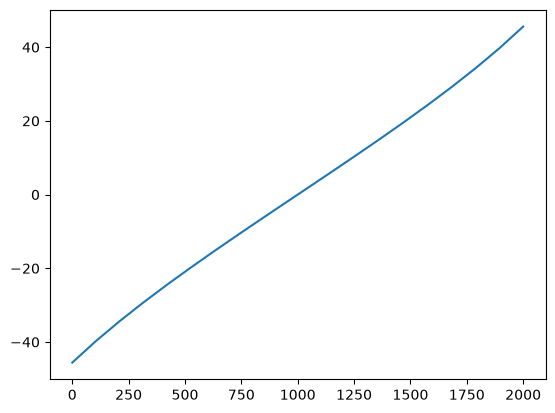

In [12]:
plt.plot(trajY2, trajPan)

In [13]:
y1.setMotor(True, 300)
y2.setMotor(True, 300)
x2.setMotor(True, 300)
pan.setMotor(True, 300)

for py1, py2, px2, ppan in zip(trajY1, trajY2, trajX2, trajPan):
    moveAndWaitMultiple([(y1, py1), (y2, py2), (x2, px2), (pan, ppan)])

moveAndWaitMultiple([(y1, 0), (y2, 0), (x2, 0), (pan, 0)])

y1.setMotor(False, -1)
y2.setMotor(False, -1)
x2.setMotor(False, -1)
pan.setMotor(False, -1)

0

In [14]:
tx.disconnect()

0

In [ ]:
y1.setMotor(True)
y2.setMotor(True)
pan.setMotor(True)
moveAndWaitMultiple()